# Validating the "Body Lean" check against expert-labelled posture data

**Project:** AI Physio Tracker (M.Sc. Data Analytics) - data-science component
**Author:** Blessy Babu

## 1. Problem and research question

The app checks sitting posture from a webcam using MediaPipe Pose landmarks. One of its checks, **Body Lean**
(`backend/app/ai/posture_analyzer.py`), is a hand-picked rule:

* take the midpoint of the hips and the midpoint of the shoulders (normalised image x, y),
* measure how far the line between them deviates from vertical,
* flag "Body Lean" if the deviation is **more than 5°** (severity "High" above 10°).

The 5° value was chosen by hand and has never been checked against real labelled data. There is also a known
problem: the angle is computed on *normalised* image coordinates, so x and y are scaled differently whenever the
frame is not square, which distorts the angle.

**Research question:** *Is the app's hand-picked 5° lean rule a good detector of poor sitting posture, and does a
model trained on expert-labelled data do better?*

To answer it, the rule and several learned models are scored on the public **MultiPosture** dataset, using
**leave-one-subject-out (LOSO)** cross-validation, so every score is measured on a person the method has never seen.

In [1]:
import json
import platform
import time
import warnings
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from scipy.stats import wilcoxon
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_fscore_support)
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

import posture_features as pf

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

SEED = 42
DATA = Path("data/data.csv")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220, "savefig.bbox": "tight"})

CLASSES = ["TUP", "TLF", "TLB", "TLL", "TLR"]
CLASS_NAMES = {"TUP": "Upright", "TLF": "Leaning forward", "TLB": "Leaning backward",
               "TLL": "Leaning left", "TLR": "Leaning right"}
PALETTE = dict(zip(CLASSES, ["#2b8a3e", "#c92a2a", "#e67700", "#1c7ed6", "#7048e8"]))

print("python", platform.python_version(), "| numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

python 3.11.8 | numpy 2.4.6 | pandas 3.0.6 | scikit-learn 1.9.1 | scipy 1.17.1 | matplotlib 3.11.2


## 2. Data

**MultiPosture** (Carneros-Prado et al., 2024; Zenodo DOI [10.5281/zenodo.14230872](https://doi.org/10.5281/zenodo.14230872),
licence CC BY 4.0). Adults were filmed sitting in front of a camera at home, the video frames were run through
MediaPipe Pose (Heavy model), and each frame was labelled by experts for upper-body (trunk) posture and lower-body
(leg) posture. The file was downloaded with `download_data.py` (checksum verified).

Only the **upper-body label** is used here, because that is what the app's Body Lean check is about:

| Code | Meaning |
|---|---|
| TUP | upright trunk |
| TLF | trunk leaning forward |
| TLB | trunk leaning backward |
| TLL | trunk leaning left |
| TLR | trunk leaning right |

In [2]:
df = pd.read_csv(DATA)
print("rows x columns:", df.shape)
coord_cols = [c for c in df.columns if c.endswith(("_x", "_y", "_z"))]
landmarks_in_file = sorted({c.rsplit("_", 1)[0] for c in coord_cols}, key=pf.LANDMARK_NAMES.index)
print("non-coordinate columns:", [c for c in df.columns if c not in coord_cols])
print(f"{len(coord_cols)} coordinate columns = {len(landmarks_in_file)} landmarks x (x, y, z)")
print("landmarks match MediaPipe's 33-point order:", landmarks_in_file == pf.LANDMARK_NAMES)
print("participants:", df["subject"].nunique(), "| frames:", len(df))
print("missing values:", int(df.isna().sum().sum()),
      "| duplicate rows:", int(df.duplicated().sum()),
      "| duplicate coordinate rows:", int(df[coord_cols].duplicated().sum()))

rows x columns: (4794, 102)
non-coordinate columns: ['subject', 'upperbody_label', 'lowerbody_label']
99 coordinate columns = 33 landmarks x (x, y, z)
landmarks match MediaPipe's 33-point order: True
participants: 13 | frames: 4794
missing values: 0 | duplicate rows: 0 | duplicate coordinate rows: 0


Note: the Zenodo description mentions "11 key body joints", but the CSV actually contains **all 33 MediaPipe
landmarks** (99 coordinate columns), which is what the app also receives. There are **4,794 frames**, slightly
fewer than the 4,800 quoted in the description.

The coordinates are MediaPipe **world landmarks**: metres, with the origin at the hip midpoint. The checks below
confirm this and confirm the direction of each axis, which matters for turning angles into "left/right" and
"forward/back".

In [3]:
def P(name):
    return df[[f"{name}_x", f"{name}_y", f"{name}_z"]].to_numpy()

hip_mid = (P("left_hip") + P("right_hip")) / 2
sh_mid = (P("left_shoulder") + P("right_shoulder")) / 2
print("hip midpoint, max |value| over all frames (x, y, z):", np.abs(hip_mid).max(axis=0).round(4))
print("median 3D shoulder width (m):", np.median(np.linalg.norm(P("left_shoulder") - P("right_shoulder"), axis=1)).round(3))
print("frames where left_shoulder_x > right_shoulder_x:",
      f"{(P('left_shoulder')[:, 0] > P('right_shoulder')[:, 0]).mean():.1%}", "-> +x is the person's LEFT")

axis_check = pd.DataFrame(sh_mid - hip_mid, columns=["dx", "dy", "dz"]).assign(label=df["upperbody_label"])
axis_check.groupby("label")[["dx", "dy", "dz"]].mean().loc[CLASSES]

hip midpoint, max |value| over all frames (x, y, z): [0.0025 0.0061 0.0028]
median 3D shoulder width (m): 0.333
frames where left_shoulder_x > right_shoulder_x: 100.0% -> +x is the person's LEFT


,dx,dy,dz
label,,,
TUP,0.023,-0.416,-0.005
TLF,0.020,-0.362,-0.186
TLB,0.016,-0.400,0.123
TLL,0.249,-0.335,-0.039
TLR,-0.212,-0.352,-0.045


The hip midpoint is at the origin to within a few millimetres, so the data is hip-centred. Relative to the hips,
the shoulder midpoint sits at negative *y* (y points down), moves to **+x for TLL** and **-x for TLR**
(+x = the person's left), and to **negative z for TLF** (closer to the camera) and **positive z for TLB**.
These signs are used for all angles below.

In [4]:
counts = df["upperbody_label"].value_counts().reindex(CLASSES)
balance = pd.DataFrame({"frames": counts, "share": (counts / len(df)).round(3)})
balance.index = [f"{c} ({CLASS_NAMES[c]})" for c in CLASSES]
display(balance)

per_subject = pd.crosstab(df["subject"], df["upperbody_label"]).reindex(columns=CLASSES)
per_subject["total"] = per_subject.sum(axis=1)
per_subject

,frames,share
TUP (Upright),1615,0.337
TLF (Leaning forward),1897,0.396
TLB (Leaning backward),442,0.092
TLL (Leaning left),420,0.088
TLR (Leaning right),420,0.088


upperbody_label,TUP,TLF,TLB,TLL,TLR,total
subject,,,,,,
1,203,163,54,60,60,540
2,236,142,12,30,30,450
3,169,240,11,30,30,480
4,168,205,47,30,30,480
5,141,243,0,30,30,444
6,131,279,10,30,30,480
7,50,144,46,30,30,300
8,61,148,1,30,30,270
9,107,62,41,30,30,270


The classes are **imbalanced**: forward lean and upright make up about 73% of the frames, while back, left and
right lean are about 9% each. Participants also contribute very different numbers of frames (270 to 540), and
participant 5 has no backward-lean frames at all. Because of the imbalance, **macro-F1** (the unweighted average of
the per-class F1 scores) is the main metric; plain accuracy would reward a model that ignores the rare classes.

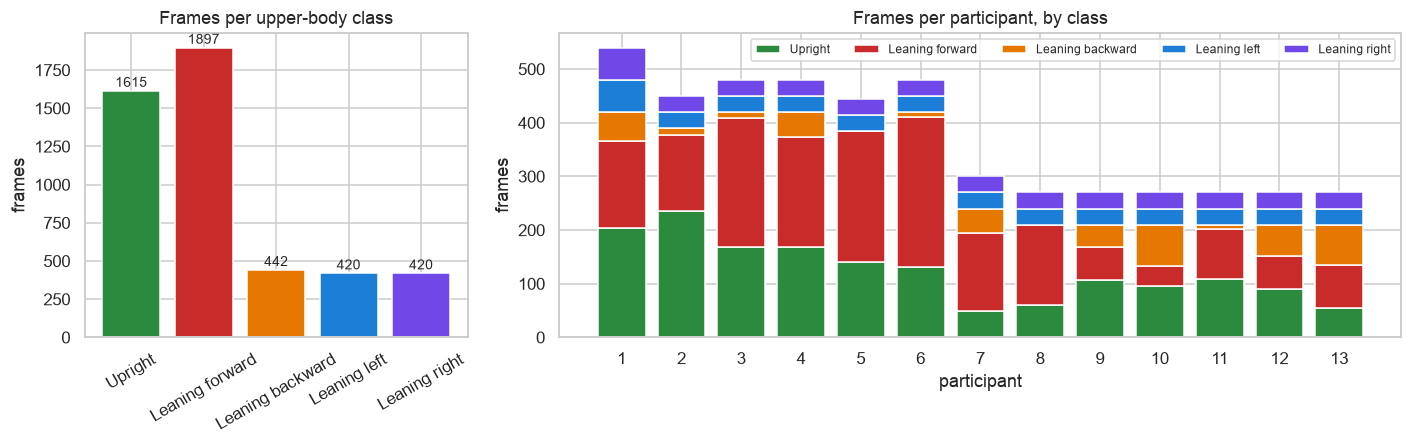

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 2.2]})
ax = axes[0]
ax.bar([CLASS_NAMES[c] for c in CLASSES], counts.values, color=[PALETTE[c] for c in CLASSES])
for i, v in enumerate(counts.values):
    ax.text(i, v + 25, f"{v}", ha="center", fontsize=9)
ax.set_title("Frames per upper-body class"); ax.set_ylabel("frames")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
bottom = np.zeros(len(per_subject))
for c in CLASSES:
    ax.bar(per_subject.index.astype(str), per_subject[c], bottom=bottom, color=PALETTE[c], label=CLASS_NAMES[c])
    bottom += per_subject[c].values
ax.set_title("Frames per participant, by class"); ax.set_xlabel("participant"); ax.set_ylabel("frames")
ax.legend(ncol=5, fontsize=8, loc="upper right", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "class_balance.png")
plt.show()

## 3. Features

Everything the model uses must be something the app can compute from MediaPipe landmarks on every frame. Two
feature sets are built.

**(A) Engineered, interpretable features** (8 numbers per frame, defined in `posture_features.py`), all from the
nose, ears, shoulders and hips:

| Feature | Meaning |
|---|---|
| `trunk_lateral_deg` | sideways lean of the hip-to-shoulder line (+ = person's left). Measured out of the sagittal plane, so it stays within +-90° even when someone bends far forward |
| `trunk_sagittal_deg` | forward/back lean of the hip-to-shoulder line in the y-z plane (+ = forward, towards the camera) |
| `shoulder_tilt_deg` | slope of the shoulder line (+ = left shoulder lower) |
| `shoulder_rotation_deg` | twist of the shoulder line in depth (+ = left shoulder further from the camera) |
| `torso_height_ratio` | vertical hip-to-shoulder distance divided by shoulder width (the torso looks shorter when leaning) |
| `head_lateral_ratio` | ear midpoint left/right of the shoulder midpoint, / shoulder width |
| `head_height_ratio` | ear midpoint height above the shoulder midpoint, / shoulder width |
| `head_forward_ratio` | ear midpoint in front of the shoulder midpoint, / shoulder width |

Dividing by shoulder width makes the ratios independent of body size.

**(B) Raw hip-centred coordinates** of the 15 upper-body landmarks (face, shoulders, hips): 45 numbers. Arms and
legs are left out on purpose, because arm and leg positions are not trunk posture (and leg position has its own
label in this dataset).

**The app's own measure** is also recomputed exactly as `posture_analyzer.py` does it: `|90 - |atan2(dy, dx)||` on the
hip-midpoint to shoulder-midpoint line, using only x and y. Here it is applied to world x, y (metres), which do
not have the aspect-ratio problem; the effect of that problem is simulated separately in section 6.5.

In [6]:
y = df["upperbody_label"].to_numpy()
groups = df["subject"].to_numpy()
subjects = np.unique(groups)

X_eng = pf.features_from_dataframe(df)
X_raw = df[pf.RAW_FEATURE_NAMES].copy()
X_all = pd.concat([X_eng, X_raw], axis=1)

# The app's Body Lean measure, same formula as posture_analyzer.py (x, y only)
dx = sh_mid[:, 0] - hip_mid[:, 0]
dy = sh_mid[:, 1] - hip_mid[:, 1]
app_dev = np.abs(90 - np.abs(np.degrees(np.arctan2(dy, dx))))
app_side = np.where(dx > 0, "TLL", "TLR")        # +x = person's left

# sanity check: the vectorised version equals the per-frame helper
assert np.allclose(app_dev[:50], [pf.app_torso_deviation(hip_mid[i, :2], sh_mid[i, :2]) for i in range(50)])
print("engineered:", X_eng.shape, "| raw:", X_raw.shape, "| combined:", X_all.shape)

summary = X_eng.assign(app_deviation_deg=app_dev, label=y).groupby("label").median().loc[CLASSES].T
summary.columns = [f"{c} median" for c in CLASSES]
summary

engineered: (4794, 8) | raw: (4794, 45) | combined: (4794, 53)


,TUP median,TLF median,TLB median,TLL median,TLR median
trunk_lateral_deg,3.156,2.489,1.989,33.343,-29.302
trunk_sagittal_deg,0.826,19.996,-15.207,8.426,9.944
shoulder_tilt_deg,9.520,8.413,9.844,29.438,-7.683
shoulder_rotation_deg,-8.904,-8.875,-6.796,-6.209,-12.842
torso_height_ratio,1.242,1.185,1.263,1.133,1.071
head_lateral_ratio,-0.029,-0.032,-0.032,0.029,-0.083
head_height_ratio,0.289,0.239,0.302,0.247,0.198
head_forward_ratio,0.447,0.527,0.369,0.499,0.438
app_deviation_deg,3.249,2.930,2.704,33.492,30.967


The medians already tell most of the story: sideways lean shows up clearly in `trunk_lateral_deg`, and forward
and backward lean show up in `trunk_sagittal_deg` (which needs the depth coordinate z). The app's measure only
looks at x and y, so it can react to sideways lean but has no way of seeing forward or backward lean from a
front camera. Note also that the **median upright frame already has an app deviation of about 3°**, close to the 5° limit.

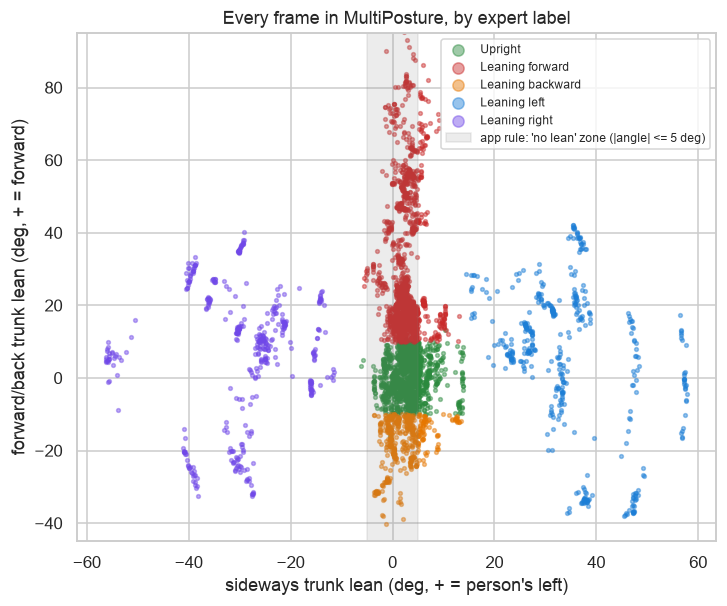

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6))
plot_df = X_eng.assign(label=y)
for c in CLASSES:
    d = plot_df[plot_df.label == c]
    ax.scatter(d.trunk_lateral_deg, d.trunk_sagittal_deg, s=6, alpha=0.45, color=PALETTE[c], label=CLASS_NAMES[c])
ax.axvspan(-5, 5, color="grey", alpha=0.15, label="app rule: 'no lean' zone (|angle| <= 5 deg)")
ax.set_xlabel("sideways trunk lean (deg, + = person's left)")
ax.set_ylabel("forward/back trunk lean (deg, + = forward)")
ax.set_title("Every frame in MultiPosture, by expert label")
ax.set_ylim(-45, 95)
ax.legend(markerscale=3, fontsize=8, loc="upper right")
fig.savefig(FIG_DIR / "lean_angles_scatter.png")
plt.show()

## 4. Methods

All methods are evaluated with **leave-one-subject-out (LOSO)** cross-validation: 13 folds, each fold trains on 12
participants and tests on the 13th. Anything that is learned (thresholds, scaling, hyper-parameters) is learned
**only from the training participants** of that fold. Hyper-parameters are tuned inside each training fold with a
4-fold `GroupKFold` (also split by participant), optimising macro-F1.

| # | Method | Features | What is learned |
|---|---|---|---|
| M0 | Majority class baseline | none | the most common class |
| M1 | **App rule as it is (5°)** | app deviation (x, y) | nothing - fixed 5° |
| M2 | App rule, threshold learned | app deviation (x, y) | the cut-off (instead of 5°) |
| M3 | Learned three-threshold rule | `trunk_lateral_deg`, `trunk_sagittal_deg` | sideways, forward and backward cut-offs |
| M4 | Logistic regression | engineered (8) | coefficients, C |
| M5 | Decision tree | engineered (8) | tree, depth and leaf size |
| M6 | Random forest | engineered (8) | forest, leaf size and features per split |
| M7 | Random forest | engineered + raw (53) | forest, leaf size and features per split |

**How the app rule is mapped onto the 5 classes (M1, M2).** The app only answers "lean or no lean", so:
deviation <= threshold -> **TUP**; deviation > threshold -> **TLL** if the shoulders are to the person's left of the hips,
otherwise **TLR**. Because the rule uses only x and y, it can never output TLF or TLB. That is not a trick of the
mapping: from a front camera, a forward or backward lean moves the shoulders towards or away from the camera, which
the 2D angle does not see. For fairness, the rule is also scored on the simpler **binary task** (upright vs any
lean), which is what the app actually shows users (section 6.6).

**M3** is what the rule would look like if it were designed from data: check `|trunk_lateral_deg|` against a
sideways cut-off first, then `trunk_sagittal_deg` against a forward and a backward cut-off. The three cut-offs are
found on the training participants by coordinate search (0-45° in 0.5° steps, three passes), maximising macro-F1.

In [8]:
def macro_f1_fast(y_true, y_pred, labels=CLASSES):
    # macro-F1 over the given labels (used only inside the threshold searches, for speed)
    f1s = []
    for c in labels:
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        f1s.append(0.0 if tp == 0 else 2 * tp / (2 * tp + fp + fn))
    return float(np.mean(f1s))


def app_rule_predict(dev, side, threshold):
    return np.where(dev > threshold, side, "TUP")


def fit_app_threshold(dev, side, y_true, grid=np.arange(0, 45.01, 0.25)):
    scores = [macro_f1_fast(y_true, app_rule_predict(dev, side, t)) for t in grid]
    return float(grid[int(np.argmax(scores))])


def three_threshold_predict(lat, sag, t_lat, t_fwd, t_back):
    return np.select([np.abs(lat) > t_lat, sag > t_fwd, sag < -t_back],
                     [np.where(lat > 0, "TLL", "TLR"), "TLF", "TLB"], default="TUP")


def fit_three_thresholds(lat, sag, y_true, grid=np.arange(0, 45.01, 0.5), passes=3):
    t = [5.0, 5.0, 5.0]                               # start at the app's 5 degrees
    for _ in range(passes):
        for k in range(3):
            scores = []
            for v in grid:
                trial = list(t); trial[k] = v
                scores.append(macro_f1_fast(y_true, three_threshold_predict(lat, sag, *trial)))
            t[k] = float(grid[int(np.argmax(scores))])
    return tuple(t)


logo = LeaveOneGroupOut()
inner_cv = GroupKFold(n_splits=4)


def loso(fit_predict):
    # Run LOSO. fit_predict(train_idx, test_idx) -> (predictions for test_idx, info dict)
    pred = np.empty(len(y), dtype=object)
    infos = []
    for tr, te in logo.split(X_eng, y, groups):
        p, info = fit_predict(tr, te)
        pred[te] = p
        infos.append({"test_subject": int(groups[te][0]), **info})
    return pred.astype(str), pd.DataFrame(infos)


def sklearn_fit_predict(estimator, X, grid=None):
    def fp(tr, te):
        if grid:
            search = GridSearchCV(estimator, grid, cv=inner_cv, scoring="f1_macro", n_jobs=-1)
            search.fit(X.iloc[tr], y[tr], groups=groups[tr])
            return search.predict(X.iloc[te]), {k: v for k, v in search.best_params_.items()}
        model = clone(estimator).fit(X.iloc[tr], y[tr])
        return model.predict(X.iloc[te]), {}
    return fp

In [9]:
lat = X_eng["trunk_lateral_deg"].to_numpy()
sag = X_eng["trunk_sagittal_deg"].to_numpy()

LR = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
DT = DecisionTreeClassifier(class_weight="balanced", random_state=SEED)
RF = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=1)

methods = {
    "M0 Majority class": lambda tr, te: (
        DummyClassifier(strategy="most_frequent").fit(X_eng.iloc[tr], y[tr]).predict(X_eng.iloc[te]), {}),
    "M1 App rule (5 deg)": lambda tr, te: (app_rule_predict(app_dev[te], app_side[te], 5.0), {"threshold": 5.0}),
    "M2 App rule, learned threshold": lambda tr, te: (
        lambda t: (app_rule_predict(app_dev[te], app_side[te], t), {"threshold": t})
    )(fit_app_threshold(app_dev[tr], app_side[tr], y[tr])),
    "M3 Learned 3-threshold rule": lambda tr, te: (
        lambda t: (three_threshold_predict(lat[te], sag[te], *t), dict(zip(["t_lateral", "t_forward", "t_backward"], t)))
    )(fit_three_thresholds(lat[tr], sag[tr], y[tr])),
    "M4 Logistic regression (eng.)": sklearn_fit_predict(
        LR, X_eng, {"logisticregression__C": [0.01, 0.1, 1, 10, 100]}),
    "M5 Decision tree (eng.)": sklearn_fit_predict(
        DT, X_eng, {"max_depth": [2, 3, 4, 5, 6, 8, None], "min_samples_leaf": [1, 5, 20]}),
    "M6 Random forest (eng.)": sklearn_fit_predict(
        RF, X_eng, {"min_samples_leaf": [1, 5], "max_features": ["sqrt", 0.5]}),
    "M7 Random forest (eng. + raw)": sklearn_fit_predict(
        RF, X_all, {"min_samples_leaf": [1, 5], "max_features": ["sqrt", 0.5]}),
}

preds, fold_info = {}, {}
for name, fp in methods.items():
    t0 = time.perf_counter()
    preds[name], fold_info[name] = loso(fp)
    print(f"{name:34s} done in {time.perf_counter() - t0:5.1f} s")

M0 Majority class                  done in   0.1 s
M1 App rule (5 deg)                done in   0.0 s


M2 App rule, learned threshold     done in   2.7 s


M3 Learned 3-threshold rule        done in  13.4 s


M4 Logistic regression (eng.)      done in  11.9 s


M5 Decision tree (eng.)            done in   5.4 s


M6 Random forest (eng.)            done in  75.0 s


M7 Random forest (eng. + raw)      done in 264.1 s


## 5. Results

### 5.1 Headline table (LOSO, 13 unseen participants)

* **Macro-F1 (pooled):** all 4,794 held-out predictions put together, then scored once.
* **Macro-F1 per participant:** scored separately for each held-out participant, then mean ± standard deviation
  across the 13 participants. This shows how much performance varies from person to person.
* **Binary F1 (poor posture):** the same predictions collapsed to *upright* (TUP) vs *poor posture* (any lean),
  which is what the app shows the user.

In [10]:
def to_binary(labels):
    return np.where(np.asarray(labels) == "TUP", "upright", "poor")


def per_subject_f1(pred):
    return pd.Series({s: f1_score(y[groups == s], pred[groups == s], average="macro", zero_division=0)
                      for s in subjects})


rows, subj_f1 = [], {}
for name, p in preds.items():
    subj_f1[name] = per_subject_f1(p)
    yb, pb = to_binary(y), to_binary(p)
    rows.append({
        "method": name,
        "macro_f1_pooled": f1_score(y, p, average="macro", labels=CLASSES, zero_division=0),
        "macro_f1_subject_mean": subj_f1[name].mean(),
        "macro_f1_subject_sd": subj_f1[name].std(ddof=1),
        "accuracy": accuracy_score(y, p),
        "binary_f1_poor": f1_score(yb, pb, pos_label="poor", zero_division=0),
        "binary_accuracy": accuracy_score(yb, pb),
    })
results = pd.DataFrame(rows).set_index("method")
subj_f1 = pd.DataFrame(subj_f1)
results.style.format("{:.3f}").background_gradient(subset=["macro_f1_pooled"], cmap="Greens")

,macro_f1_pooled,macro_f1_subject_mean,macro_f1_subject_sd,accuracy,binary_f1_poor,binary_accuracy
method,,,,,,
M0 Majority class,0.113,0.110,0.035,0.396,0.797,0.663
M1 App rule (5 deg),0.417,0.436,0.043,0.457,0.546,0.551
"M2 App rule, learned threshold",0.494,0.496,0.069,0.504,0.427,0.517
M3 Learned 3-threshold rule,0.990,0.991,0.018,0.993,0.995,0.994
M4 Logistic regression (eng.),0.973,0.974,0.038,0.981,0.993,0.991
M5 Decision tree (eng.),0.995,0.996,0.008,0.996,0.999,0.998
M6 Random forest (eng.),0.995,0.996,0.008,0.996,0.999,0.998
M7 Random forest (eng. + raw),0.995,0.995,0.008,0.996,0.998,0.998


In [11]:
best_name = results["macro_f1_pooled"].idxmax()
rule_name = "M1 App rule (5 deg)"
print("best method by pooled macro-F1:", best_name)
print("\nhyper-parameters chosen inside each training fold:")
for name in ["M4 Logistic regression (eng.)", "M5 Decision tree (eng.)", "M6 Random forest (eng.)", "M7 Random forest (eng. + raw)"]:
    fi = fold_info[name].drop(columns="test_subject")
    print(f"  {name}:", fi.astype(str).agg(", ".join, axis=1).value_counts().to_dict())

best method by pooled macro-F1: M7 Random forest (eng. + raw)

hyper-parameters chosen inside each training fold:
  M4 Logistic regression (eng.): {'100': 11, '10': 2}
  M5 Decision tree (eng.): {'4, 1': 12, '8, 1': 1}
  M6 Random forest (eng.): {'0.5, 1': 12, '0.5, 5': 1}
  M7 Random forest (eng. + raw): {'0.5, 1': 9, '0.5, 5': 3, 'sqrt, 1': 1}


### 5.2 Per-class precision and recall

In [12]:
def per_class_table(pred):
    p, r, f, s = precision_recall_fscore_support(y, pred, labels=CLASSES, zero_division=0)
    return pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": s}, index=CLASSES)

for name in [rule_name, "M3 Learned 3-threshold rule", "M5 Decision tree (eng.)", best_name]:
    print(name)
    display(per_class_table(preds[name]).style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"}))

M1 App rule (5 deg)


,precision,recall,f1,support
TUP,0.417,0.836,0.556,1615
TLF,0.000,0.000,0.000,1897
TLB,0.000,0.000,0.000,442
TLL,0.375,1.000,0.545,420
TLR,0.963,1.000,0.981,420


M3 Learned 3-threshold rule


,precision,recall,f1,support
TUP,0.996,0.985,0.990,1615
TLF,0.996,1.000,0.998,1897
TLB,0.998,0.998,0.998,442
TLL,0.955,1.000,0.977,420
TLR,1.000,0.976,0.988,420


M5 Decision tree (eng.)


,precision,recall,f1,support
TUP,1.000,0.995,0.998,1615
TLF,0.993,1.000,0.996,1897
TLB,0.995,1.000,0.998,442
TLL,0.993,0.974,0.983,420
TLR,1.000,1.000,1.000,420


M7 Random forest (eng. + raw)


,precision,recall,f1,support
TUP,0.996,0.997,0.997,1615
TLF,0.994,0.999,0.997,1897
TLB,0.995,1.000,0.998,442
TLL,1.000,0.981,0.990,420
TLR,1.000,0.988,0.994,420


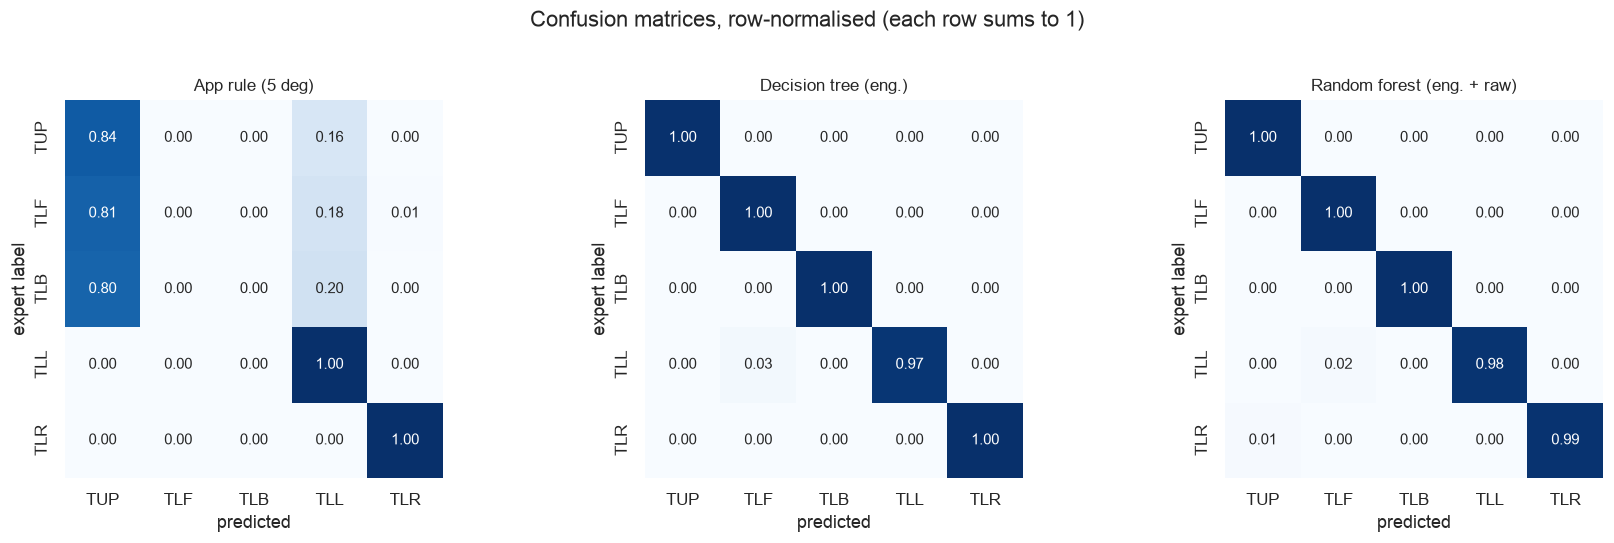

In [13]:
def plot_cm(pred, title, path, ax=None):
    cm = confusion_matrix(y, pred, labels=CLASSES, normalize="true")
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(5.4, 4.6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=own, square=True, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"size": 10})
    ax.set_xlabel("predicted"); ax.set_ylabel("expert label"); ax.set_title(title, fontsize=11)
    if own:
        fig.savefig(path); plt.close(fig)
    return cm

cm_rule = plot_cm(preds[rule_name], "App rule (5 deg), LOSO", FIG_DIR / "confusion_app_rule.png")
cm_best = plot_cm(preds[best_name], f"{best_name[3:]}, LOSO", FIG_DIR / "confusion_best_model.png")
cm_tree = plot_cm(preds["M5 Decision tree (eng.)"], "Decision tree (eng.), LOSO", FIG_DIR / "confusion_decision_tree.png")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_cm(preds[rule_name], "App rule (5 deg)", None, ax=axes[0])
plot_cm(preds["M5 Decision tree (eng.)"], "Decision tree (eng.)", None, ax=axes[1])
plot_cm(preds[best_name], best_name[3:], None, ax=axes[2])
fig.suptitle("Confusion matrices, row-normalised (each row sums to 1)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "confusion_rule_vs_best.png")
plt.show()

### 5.3 Per-participant comparison and paired test

Each participant gives one macro-F1 per method, so the methods can be compared **paired by participant** with a
Wilcoxon signed-rank test (non-parametric, suitable for 13 pairs).

In [14]:
def paired_test(a, b):
    diff = subj_f1[a] - subj_f1[b]
    if (diff == 0).all():
        stat, p = np.nan, 1.0          # identical on every participant: nothing to test
    else:
        stat, p = wilcoxon(subj_f1[a], subj_f1[b])
    return {"a": a, "b": b, "median_difference": float(diff.median()), "a_better_in": int((diff > 0).sum()),
            "ties": int((diff == 0).sum()), "n": len(diff), "W": float(stat), "p_value": float(p)}

tests = pd.DataFrame([
    paired_test(best_name, rule_name),
    paired_test("M2 App rule, learned threshold", rule_name),
    paired_test("M5 Decision tree (eng.)", rule_name),
    paired_test(best_name, "M3 Learned 3-threshold rule"),
    paired_test(best_name, "M5 Decision tree (eng.)"),
])
tests

,a,b,median_difference,a_better_in,ties,n,W,p_value
0,M7 Random forest (eng. + raw),M1 App rule (5 deg),0.559,13,0,13,0.0,2.441e-04
1,"M2 App rule, learned threshold",M1 App rule (5 deg),0.064,11,0,13,8.0,6.104e-03
2,M5 Decision tree (eng.),M1 App rule (5 deg),0.559,13,0,13,0.0,2.441e-04
3,M7 Random forest (eng. + raw),M3 Learned 3-threshold rule,0.000,3,8,13,6.0,8.125e-01
4,M7 Random forest (eng. + raw),M5 Decision tree (eng.),0.000,2,10,13,3.0,1.000e+00


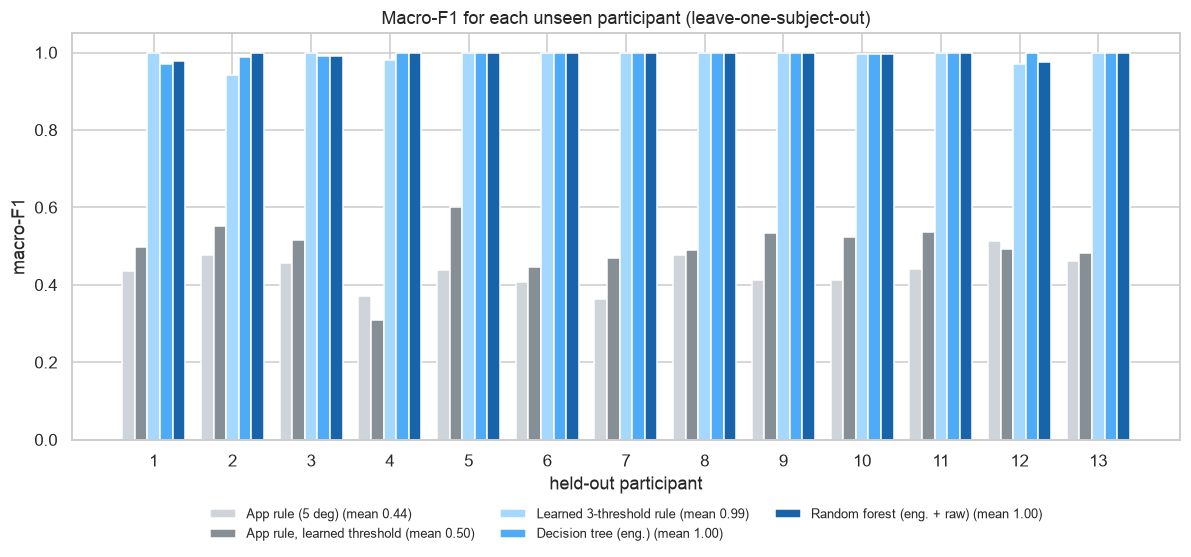

In [15]:
show = [rule_name, "M2 App rule, learned threshold", "M3 Learned 3-threshold rule", "M5 Decision tree (eng.)", best_name]
colors = ["#ced4da", "#868e96", "#a5d8ff", "#4dabf7", "#1864ab"]
fig, ax = plt.subplots(figsize=(13, 4.8))
w = 0.16
x = np.arange(len(subjects))
for i, (name, col) in enumerate(zip(show, colors)):
    ax.bar(x + (i - 2) * w, subj_f1[name].values, w, color=col, label=f"{name[3:]} (mean {subj_f1[name].mean():.2f})")
ax.set_xticks(x); ax.set_xticklabels(subjects)
ax.set_xlabel("held-out participant"); ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1.05)
ax.set_title("Macro-F1 for each unseen participant (leave-one-subject-out)")
ax.legend(ncol=3, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
fig.savefig(FIG_DIR / "per_participant_f1.png")
plt.show()

## 6. Deeper analysis

### 6.1 Is 5° the right threshold? (learned vs hand-picked)

M2 learned cut-off across the 13 training folds: median 14.75 deg (range 14.00-15.75) vs the app's 5 deg
M3 learned cut-offs (median over folds): {'t_lateral': 14.0, 't_forward': 10.0, 't_backward': 10.0}
M3 learned cut-offs (range over folds): {'t_lateral': (np.float64(13.5), np.float64(14.0)), 't_forward': (np.float64(10.0), np.float64(10.0)), 't_backward': (np.float64(10.0), np.float64(10.0))}

upright (TUP) frames with app deviation > 5 deg, i.e. false 'Body Lean' alarms: 16.4% (265 of 1615)
upright frames flagged 'High' (> 10 deg): 2.6%
95th percentile of app deviation in upright frames: 8.3 deg


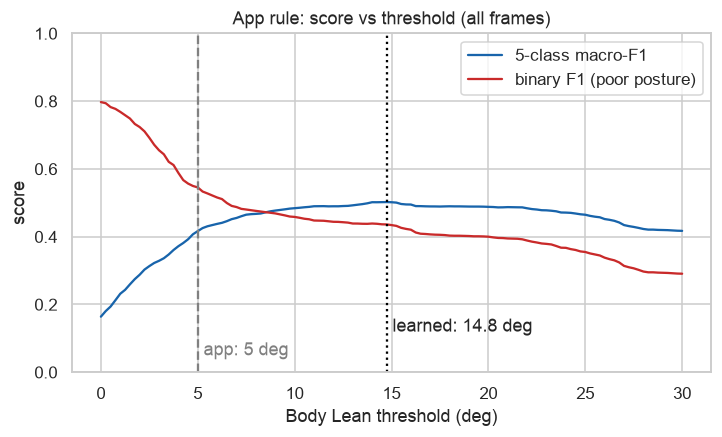

In [16]:
thr = fold_info["M2 App rule, learned threshold"]["threshold"]
t3 = fold_info["M3 Learned 3-threshold rule"][["t_lateral", "t_forward", "t_backward"]]
print(f"M2 learned cut-off across the 13 training folds: median {thr.median():.2f} deg "
      f"(range {thr.min():.2f}-{thr.max():.2f}) vs the app's 5 deg")
print("M3 learned cut-offs (median over folds):", t3.median().to_dict())
print("M3 learned cut-offs (range over folds):", {c: (t3[c].min(), t3[c].max()) for c in t3})

tup_dev = app_dev[y == "TUP"]
print(f"\nupright (TUP) frames with app deviation > 5 deg, i.e. false 'Body Lean' alarms: "
      f"{(tup_dev > 5).mean():.1%} ({(tup_dev > 5).sum()} of {len(tup_dev)})")
print(f"upright frames flagged 'High' (> 10 deg): {(tup_dev > 10).mean():.1%}")
print("95th percentile of app deviation in upright frames: %.1f deg" % np.percentile(tup_dev, 95))

# macro-F1 of the app rule across possible thresholds (on all data; descriptive only)
grid = np.arange(0, 30.01, 0.25)
curve = [f1_score(y, app_rule_predict(app_dev, app_side, t), average="macro", labels=CLASSES) for t in grid]
curve_bin = [f1_score(to_binary(y), to_binary(app_rule_predict(app_dev, app_side, t)), pos_label="poor") for t in grid]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(grid, curve, label="5-class macro-F1", color="#1864ab")
ax.plot(grid, curve_bin, label="binary F1 (poor posture)", color="#c92a2a")
ax.axvline(5, ls="--", color="grey"); ax.text(5.3, 0.05, "app: 5 deg", color="grey")
ax.axvline(thr.median(), ls=":", color="black"); ax.text(thr.median() + 0.3, 0.12, f"learned: {thr.median():.1f} deg")
ax.set_xlabel("Body Lean threshold (deg)"); ax.set_ylabel("score"); ax.set_ylim(0, 1)
ax.set_title("App rule: score vs threshold (all frames)"); ax.legend()
fig.savefig(FIG_DIR / "rule_threshold_curve.png")
plt.show()

### 6.2 Where does the rule go wrong?

In [17]:
p_rule = preds[rule_name]
err = pd.crosstab(pd.Series(y, name="expert label"), pd.Series(p_rule, name="rule output")).reindex(index=CLASSES)
err

rule output,TLL,TLR,TUP
expert label,,,
TUP,263,2,1350
TLF,349,14,1534
TLB,89,0,353
TLL,420,0,0
TLR,0,420,0


### 6.3 A surprise in the data: the labels have a sharp 10° edge

While fitting the three-threshold rule (M3), the learned forward and backward cut-offs came out at **exactly 10.0°
in every one of the 13 folds**. Looking at the raw distribution explains why.

trunk_sagittal_deg          trunk_lateral_deg        
                     min      max               min     max
label                                                      
TUP              -15.950   13.250            -6.270  13.930
TLF               10.011  122.605            -5.688  13.099
TLB              -40.181   -9.997            -3.664  13.386
TLL              -37.934   42.202            14.390  57.863
TLR              -32.529   40.095           -56.232 -11.506

upright frames beyond +-10 deg forward/back: 4 of 1615
forward-lean frames between 10 and 11 deg: 75, below 10 deg: 0
backward-lean frames between -11 and -10 deg: 56, above -10 deg: 1


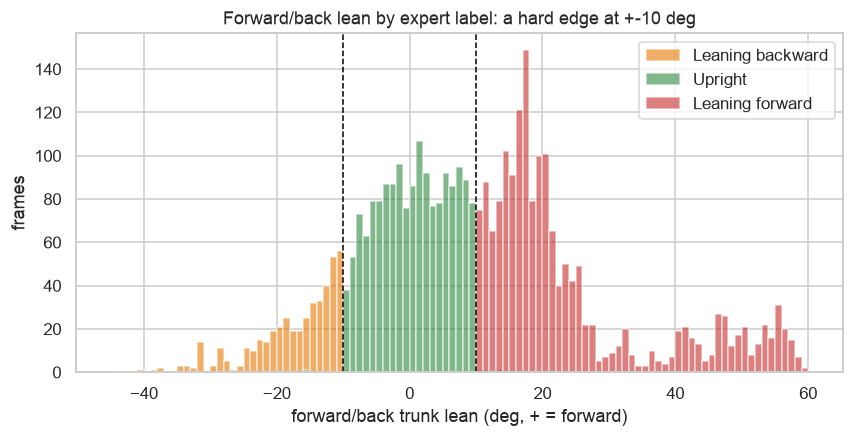

In [18]:
edges = X_eng.assign(label=y).groupby("label")[["trunk_sagittal_deg", "trunk_lateral_deg"]].agg(["min", "max"]).loc[CLASSES]
display(edges)
tup_sag = X_eng.loc[y == "TUP", "trunk_sagittal_deg"]
print(f"upright frames beyond +-10 deg forward/back: {(tup_sag.abs() > 10).sum()} of {len(tup_sag)}")
f_sag = X_eng.loc[y == "TLF", "trunk_sagittal_deg"]; b_sag = X_eng.loc[y == "TLB", "trunk_sagittal_deg"]
print(f"forward-lean frames between 10 and 11 deg: {((f_sag >= 10) & (f_sag < 11)).sum()}, below 10 deg: {(f_sag < 10).sum()}")
print(f"backward-lean frames between -11 and -10 deg: {((b_sag <= -10) & (b_sag > -11)).sum()}, above -10 deg: {(b_sag > -10).sum()}")

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(-45, 60.5, 1)
for c in ["TLB", "TUP", "TLF"]:
    ax.hist(X_eng.loc[y == c, "trunk_sagittal_deg"], bins=bins, alpha=0.6, color=PALETTE[c], label=CLASS_NAMES[c])
for v in (-10, 10):
    ax.axvline(v, color="black", ls="--", lw=1)
ax.set_xlabel("forward/back trunk lean (deg, + = forward)"); ax.set_ylabel("frames")
ax.set_title("Forward/back lean by expert label: a hard edge at +-10 deg")
ax.legend()
fig.savefig(FIG_DIR / "sagittal_label_edge.png")
plt.show()

No forward-lean frame has a forward angle below 10° and only one backward-lean frame lies above -10° (at -9.997°),
yet dozens of lean frames sit just past the line (75 forward-lean frames between 10° and 11°). Real posture does not stop abruptly at 10°, so this looks like the forward/back
labels (or the choice of which frames to keep) followed a 10° criterion on almost exactly this angle. The
sideways classes also leave a gap: no left/right-lean frame has a sideways angle under 11.5°.

**Why this matters:** the dataset contains mostly *clear-cut* leans and very few borderline frames. A model that
learns "more than about 10° forward = leaning forward" will score almost perfectly here. The near-perfect scores
below should therefore be read as "the model has recovered the labelling criterion", **not** as proof that it
will be 99% right on subtle, real-life slouching.

### 6.4 Does a random frame split give an honest score? (data leakage)

The frames come from continuous videos, so neighbouring frames are almost identical. If frames are split at random,
frames of the *same person* (often the same second of video) end up in both training and test sets, and the test
becomes a memory test. The same models (fixed, default-style settings) are scored on a single random 80/20 split
and with LOSO. A 1-nearest-neighbour classifier on the raw coordinates is added because it is the clearest
example of pure memorisation.

In [19]:
leak_models = {
    "Logistic regression (eng.)": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced")), X_eng),
    "Decision tree, no depth limit (eng.)": (DecisionTreeClassifier(random_state=SEED), X_eng),
    "Random forest (eng. + raw)": (RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1), X_all),
    "1-nearest neighbour (raw)": (make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)), X_raw),
}
idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=SEED)
leak_rows = []
for name, (est, X) in leak_models.items():
    p_rand = clone(est).fit(X.iloc[idx_tr], y[idx_tr]).predict(X.iloc[idx_te])
    p_loso, _ = loso(sklearn_fit_predict(est, X))
    leak_rows.append({"model": name,
                      "random split macro-F1": f1_score(y[idx_te], p_rand, average="macro"),
                      "random split accuracy": accuracy_score(y[idx_te], p_rand),
                      "LOSO macro-F1": f1_score(y, p_loso, average="macro"),
                      "LOSO accuracy": accuracy_score(y, p_loso)})
leak = pd.DataFrame(leak_rows).set_index("model")
leak["inflation (F1 points)"] = 100 * (leak["random split macro-F1"] - leak["LOSO macro-F1"])
leak

,random split macro-F1,random split accuracy,LOSO macro-F1,LOSO accuracy,inflation (F1 points)
model,,,,,
Logistic regression (eng.),0.979,0.978,0.958,0.964,2.098
"Decision tree, no depth limit (eng.)",0.999,0.998,0.994,0.995,0.439
Random forest (eng. + raw),0.996,0.996,0.990,0.992,0.593
1-nearest neighbour (raw),0.975,0.973,0.914,0.914,6.039


### 6.5 The aspect-ratio bug in the app

The app computes the angle on normalised image coordinates, where x is divided by the frame width and y by the frame
height. For a non-square frame this squeezes horizontal distances: a true sideways angle θ is measured as
`atan(tan θ × height / width)`. So the app only fires when the **true** lean is larger than 5°:

* 640×480 (4:3, the size used in `PoseOverlay.tsx`): true threshold = atan(tan 5° × 4/3)
* 1280×720 (16:9, a common laptop webcam): true threshold = atan(tan 5° × 16/9)

This is an approximation (it ignores camera perspective), but it shows the direction and size of the effect.

In [20]:
aspect_rows = []
for label, w_over_h in [("world coordinates (no distortion)", 1.0), ("640x480 frame (4:3)", 4 / 3), ("1280x720 frame (16:9)", 16 / 9)]:
    eff = float(np.degrees(np.arctan(np.tan(np.radians(5)) * w_over_h)))
    p = app_rule_predict(app_dev, app_side, eff)
    aspect_rows.append({"setting": label, "true-angle threshold (deg)": eff,
                        "macro-F1 (5 class)": f1_score(y, p, average="macro", labels=CLASSES),
                        "binary F1 (poor)": f1_score(to_binary(y), to_binary(p), pos_label="poor"),
                        "upright frames falsely flagged": (p[y == "TUP"] != "TUP").mean()})
aspect = pd.DataFrame(aspect_rows).set_index("setting")
aspect

,true-angle threshold (deg),macro-F1 (5 class),binary F1 (poor),upright frames falsely flagged
setting,,,,
world coordinates (no distortion),5.000,0.417,0.546,0.164
640x480 frame (4:3),6.654,0.451,0.493,0.087
1280x720 frame (16:9),8.841,0.475,0.471,0.037


### 6.6 The binary view: "upright" vs "poor posture"

This is what the user actually sees (a Body Lean warning or not). Here the rule gets full credit for flagging any
lean, even if it cannot tell which direction. Positive class = poor posture.

In [21]:
yb = to_binary(y)
bin_rows = []
for name, p in preds.items():
    pb = to_binary(p)
    pr, rc, f, _ = precision_recall_fscore_support(yb, pb, labels=["poor"], zero_division=0)
    bin_rows.append({"method": name, "precision (poor)": pr[0], "recall (poor)": rc[0], "F1 (poor)": f[0],
                     "specificity (upright kept)": np.mean(pb[yb == "upright"] == "upright"),
                     "balanced accuracy": balanced_accuracy_score(yb, pb), "accuracy": accuracy_score(yb, pb)})
binary = pd.DataFrame(bin_rows).set_index("method")
binary

,precision (poor),recall (poor),F1 (poor),specificity (upright kept),balanced accuracy,accuracy
method,,,,,,
M0 Majority class,0.663,1.000,0.797,0.000,0.500,0.663
M1 App rule (5 deg),0.830,0.406,0.546,0.836,0.621,0.551
"M2 App rule, learned threshold",1.000,0.271,0.427,1.000,0.636,0.517
M3 Learned 3-threshold rule,0.992,0.998,0.995,0.985,0.991,0.994
M4 Logistic regression (eng.),0.991,0.996,0.993,0.982,0.989,0.991
M5 Decision tree (eng.),0.997,1.000,0.999,0.995,0.998,0.998
M6 Random forest (eng.),0.997,1.000,0.999,0.995,0.998,0.998
M7 Random forest (eng. + raw),0.998,0.998,0.998,0.997,0.998,0.998


In [22]:
# Recall of the rule for each type of lean: which poor postures does it catch at all?
caught = pd.Series({c: np.mean(to_binary(p_rule[y == c]) == "poor") for c in CLASSES[1:]}, name="share flagged by app rule")
caught.index = [CLASS_NAMES[c] for c in caught.index]
caught.to_frame()

,share flagged by app rule
Leaning forward,0.191
Leaning backward,0.201
Leaning left,1.000
Leaning right,1.000


### 6.7 What if only x and y are used (as the app does today)?

The app currently passes normalised image landmarks (x, y) to the analyser. To check how much the depth coordinate
matters, the models are retrained on 2D-only versions of the features (sideways angle from x-y, shoulder tilt, torso
height ratio, head sideways and height ratios; no z anywhere). This uses world x, y, which is close to, but not the
same as, image x, y.

In [23]:
L2, R2 = P("left_shoulder")[:, :2], P("right_shoulder")[:, :2]
ear2 = ((P("left_ear") + P("right_ear")) / 2)[:, :2]
sw2 = np.linalg.norm(L2 - R2, axis=1)
up2 = hip_mid[:, 1] - sh_mid[:, 1]
X_2d = pd.DataFrame({
    "lateral_2d_deg": np.degrees(np.arctan2(sh_mid[:, 0] - hip_mid[:, 0], up2)),
    "shoulder_tilt_deg": X_eng["shoulder_tilt_deg"],
    "torso_height_ratio_2d": up2 / sw2,
    "head_lateral_ratio_2d": (ear2[:, 0] - sh_mid[:, 0]) / sw2,
    "head_height_ratio_2d": (sh_mid[:, 1] - ear2[:, 1]) / sw2,
})
rows_2d = []
for name, est in [("Logistic regression", LR), ("Random forest", RF)]:
    for fs_name, X in [("2D only (x, y)", X_2d), ("engineered 3D", X_eng)]:
        p, _ = loso(sklearn_fit_predict(est, X))
        rows_2d.append({"model": name, "features": fs_name, "macro-F1 (LOSO)": f1_score(y, p, average="macro"),
                        "accuracy": accuracy_score(y, p),
                        "TLF recall": np.mean(p[y == "TLF"] == "TLF"), "TLB recall": np.mean(p[y == "TLB"] == "TLB")})
pd.DataFrame(rows_2d).set_index(["model", "features"])

macro-F1 (LOSO)  accuracy  TLF recall  TLB recall
model               features                                                         
Logistic regression 2D only (x, y)            0.640     0.570       0.616       0.448
                    engineered 3D             0.958     0.964       0.972       0.975
Random forest       2D only (x, y)            0.662     0.615       0.627       0.170
                    engineered 3D             0.990     0.993       0.999       1.000

### 6.8 Which features matter?

Permutation importance measures how much macro-F1 drops on the **held-out participant** when one feature is
shuffled. It is computed inside each LOSO fold and averaged over the 13 folds, so it describes generalisation to new
people, not just the training fit.

In [24]:
def loso_permutation_importance(estimator, X, n_repeats=10):
    imps = []
    for tr, te in logo.split(X, y, groups):
        model = clone(estimator).fit(X.iloc[tr], y[tr])
        r = permutation_importance(model, X.iloc[te], y[te], scoring="f1_macro", n_repeats=n_repeats,
                                   random_state=SEED, n_jobs=-1)
        imps.append(r.importances_mean)
    imps = np.array(imps)
    return pd.DataFrame({"mean drop in macro-F1": imps.mean(axis=0), "sd across participants": imps.std(axis=0, ddof=1)},
                        index=X.columns).sort_values("mean drop in macro-F1", ascending=False)

imp_rf = loso_permutation_importance(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1), X_eng)
imp_rf

,mean drop in macro-F1,sd across participants
trunk_lateral_deg,4.279e-01,5.559e-02
trunk_sagittal_deg,3.778e-01,4.069e-02
shoulder_tilt_deg,2.063e-02,4.635e-02
head_height_ratio,4.799e-04,1.868e-03
shoulder_rotation_deg,2.477e-04,1.148e-03
head_lateral_ratio,3.446e-06,1.242e-05
torso_height_ratio,-3.778e-04,2.810e-03
head_forward_ratio,-8.044e-04,2.775e-03


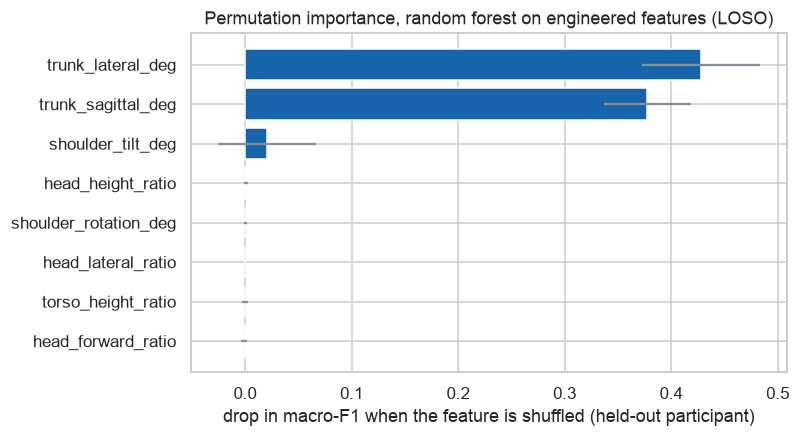

Top 10 impurity importances, random forest on engineered + raw features:


trunk_sagittal_deg    0.097
trunk_lateral_deg     0.068
right_shoulder_x      0.060
left_shoulder_z       0.059
left_shoulder_x       0.054
left_ear_x            0.049
mouth_left_z          0.044
right_shoulder_z      0.042
mouth_left_x          0.041
right_ear_x           0.040
dtype: float64

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_rf.index[::-1], imp_rf["mean drop in macro-F1"][::-1], xerr=imp_rf["sd across participants"][::-1],
        color="#1864ab", ecolor="#868e96")
ax.set_xlabel("drop in macro-F1 when the feature is shuffled (held-out participant)")
ax.set_title("Permutation importance, random forest on engineered features (LOSO)")
fig.savefig(FIG_DIR / "feature_importance.png")
plt.show()

rf_all = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1).fit(X_all, y)
print("Top 10 impurity importances, random forest on engineered + raw features:")
pd.Series(rf_all.feature_importances_, index=X_all.columns).sort_values(ascending=False).head(10).round(3)

## 7. Choosing and saving a model for the app

Rule for choosing: among the models that use **only the 8 engineered features** (cheap to compute from MediaPipe
landmarks on every frame, and easy to explain), pick the **simplest one whose pooled LOSO macro-F1 is within 0.02 of
the best method**. Order of simplicity: logistic regression, then a single decision tree, then a random forest.

The chosen model is then retrained on **all 13 participants**, with its hyper-parameters tuned by LOSO on the full
data, and saved with `joblib`.

In [26]:
best_f1 = results.loc[best_name, "macro_f1_pooled"]
candidates = ["M4 Logistic regression (eng.)", "M5 Decision tree (eng.)", "M6 Random forest (eng.)"]
estimators = {"M4 Logistic regression (eng.)": (LR, {"logisticregression__C": [0.01, 0.1, 1, 10, 100]}),
              "M5 Decision tree (eng.)": (DT, {"max_depth": [2, 3, 4, 5, 6, 8, None], "min_samples_leaf": [1, 5, 20]}),
              "M6 Random forest (eng.)": (RF, {"min_samples_leaf": [1, 5], "max_features": ["sqrt", 0.5]})}
for c in candidates:
    gap = best_f1 - results.loc[c, "macro_f1_pooled"]
    print(f"{c:32s} pooled macro-F1 {results.loc[c, 'macro_f1_pooled']:.3f}  gap to best {gap:+.3f}")
deploy_name = next(c for c in candidates if best_f1 - results.loc[c, "macro_f1_pooled"] <= 0.02)
print("\nchosen for deployment:", deploy_name)

est, grid = estimators[deploy_name]
final_search = GridSearchCV(est, grid, cv=logo, scoring="f1_macro", n_jobs=-1).fit(X_eng, y, groups=groups)
final_model = final_search.best_estimator_
print("hyper-parameters (tuned by LOSO on all 13 participants):", final_search.best_params_)
print(f"LOSO macro-F1 of that setting during tuning: {final_search.best_score_:.3f} (mean over participants; "
      "slightly optimistic because it was used to pick the setting - the honest estimate is the nested LOSO score above)")

M4 Logistic regression (eng.)    pooled macro-F1 0.973  gap to best +0.022
M5 Decision tree (eng.)          pooled macro-F1 0.995  gap to best +0.000
M6 Random forest (eng.)          pooled macro-F1 0.995  gap to best +0.000

chosen for deployment: M5 Decision tree (eng.)


hyper-parameters (tuned by LOSO on all 13 participants): {'max_depth': 4, 'min_samples_leaf': 1}
LOSO macro-F1 of that setting during tuning: 0.996 (mean over participants; slightly optimistic because it was used to pick the setting - the honest estimate is the nested LOSO score above)


In [27]:
if isinstance(final_model, DecisionTreeClassifier):
    print(f"depth {final_model.get_depth()}, {final_model.get_n_leaves()} leaves\n")
    print(export_text(final_model, feature_names=pf.FEATURE_NAMES, decimals=1))

depth 4, 7 leaves

|--- trunk_lateral_deg <= -8.9
|   |--- class: TLR
|--- trunk_lateral_deg >  -8.9
|   |--- trunk_lateral_deg <= 14.2
|   |   |--- trunk_sagittal_deg <= -10.0
|   |   |   |--- shoulder_tilt_deg <= 4.8
|   |   |   |   |--- class: TLB
|   |   |   |--- shoulder_tilt_deg >  4.8
|   |   |   |   |--- class: TLB
|   |   |--- trunk_sagittal_deg >  -10.0
|   |   |   |--- trunk_sagittal_deg <= 10.0
|   |   |   |   |--- class: TUP
|   |   |   |--- trunk_sagittal_deg >  10.0
|   |   |   |   |--- class: TLF
|   |--- trunk_lateral_deg >  14.2
|   |   |--- head_lateral_ratio <= -0.2
|   |   |   |--- class: TLL
|   |   |--- head_lateral_ratio >  -0.2
|   |   |   |--- class: TLL



In [28]:
bundle = {
    "model": final_model,
    "feature_names": pf.FEATURE_NAMES,
    "classes": list(final_model.classes_),
    "class_descriptions": CLASS_NAMES,
    "input": "MediaPipe Pose world landmarks (pose_world_landmarks), 33 points, metres, hip-centred",
    "feature_code": "analysis/posture_features.py -> features_from_landmarks()",
    "training_data": "MultiPosture (Carneros-Prado et al., 2024), doi:10.5281/zenodo.14230872, CC BY 4.0",
    "loso_macro_f1_pooled": float(results.loc[deploy_name, "macro_f1_pooled"]),
    "sklearn_version": sklearn.__version__,
}
model_path = MODEL_DIR / "posture_lean_model.joblib"
joblib.dump(bundle, model_path)
print(f"saved {model_path} ({model_path.stat().st_size / 1024:.1f} KB)")

# reload and check it predicts the same as in memory
reloaded = joblib.load(model_path)
assert (reloaded["model"].predict(X_eng) == final_model.predict(X_eng)).all()
print("reload check OK; training-set accuracy (not a real score):", round(accuracy_score(y, final_model.predict(X_eng)), 4))

saved models/posture_lean_model.joblib (3.9 KB)
reload check OK; training-set accuracy (not a real score): 0.9992


### 7.1 Inference time per frame

Timed on this laptop for a single frame, the way the app would call it: 33 world landmarks in, feature computation,
then `predict_proba`. The rule and the large random forest are timed the same way for comparison.

In [29]:
def frame_landmarks(i):
    row = df.iloc[i]
    return [{"x": row[f"{n}_x"], "y": row[f"{n}_y"], "z": row[f"{n}_z"]} for n in pf.LANDMARK_NAMES]

frames = [frame_landmarks(i) for i in np.random.default_rng(SEED).choice(len(df), 200, replace=False)]

def time_per_frame(fn, repeats=5):
    fn(frames[0])                      # warm-up
    t = []
    for _ in range(repeats):
        for f in frames:
            t0 = time.perf_counter(); fn(f); t.append(time.perf_counter() - t0)
    return np.median(t) * 1000, np.percentile(t, 95) * 1000

feat_df = lambda f: pd.DataFrame(pf.features_from_landmarks(f), columns=pf.FEATURE_NAMES)
rf_eng_raw = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=1).fit(X_all, y)

def rf_all_fn(f):
    x = pd.DataFrame(np.hstack([pf.features_from_landmarks(f),
                                [[lm[a] for n, lm in zip(pf.LANDMARK_NAMES, f) if n in pf.RAW_LANDMARKS for a in "xyz"]]]),
                     columns=X_all.columns)
    return rf_eng_raw.predict_proba(x)

def app_rule_fn(f):
    hip = ((f[23]["x"] + f[24]["x"]) / 2, (f[23]["y"] + f[24]["y"]) / 2)
    sh = ((f[11]["x"] + f[12]["x"]) / 2, (f[11]["y"] + f[12]["y"]) / 2)
    return pf.app_torso_deviation(hip, sh) > 5

timing = {}
for name, fn in [("App rule (5 deg)", app_rule_fn),
                 (f"Deployed: {deploy_name[3:]}", lambda f: final_model.predict_proba(feat_df(f))),
                 ("Random forest (eng. + raw, 300 trees)", rf_all_fn)]:
    med, p95 = time_per_frame(fn)
    timing[name] = {"median_ms": med, "p95_ms": p95}
timing = pd.DataFrame(timing).T
print("machine:", platform.platform(), platform.processor())
timing

machine: macOS-26.6.2-arm64-arm-64bit arm


,median_ms,p95_ms
App rule (5 deg),8.750e-04,0.004
Deployed: Decision tree (eng.),4.958e-01,0.844
"Random forest (eng. + raw, 300 trees)",1.199e+01,17.793


### 7.2 Save the key numbers

In [30]:
def r(x, n=4):
    return round(float(x), n)

res_json = {
    "dataset": {"name": "MultiPosture", "doi": "10.5281/zenodo.14230872", "licence": "CC BY 4.0",
                "frames": int(len(df)), "participants": int(df["subject"].nunique()),
                "class_counts": {c: int(counts[c]) for c in CLASSES}},
    "evaluation": "leave-one-subject-out (13 folds); tuning inside training folds with GroupKFold(4)",
    "methods": {name: {"macro_f1_pooled": r(row.macro_f1_pooled),
                       "macro_f1_per_participant_mean": r(row.macro_f1_subject_mean),
                       "macro_f1_per_participant_sd": r(row.macro_f1_subject_sd),
                       "accuracy": r(row.accuracy),
                       "binary_f1_poor_posture": r(row.binary_f1_poor),
                       "binary_accuracy": r(row.binary_accuracy)} for name, row in results.iterrows()},
    "best_method": best_name,
    "deployed_model": {"method": deploy_name, "file": "models/posture_lean_model.joblib",
                       "hyperparameters": {k: (None if v is None else v) for k, v in final_search.best_params_.items()},
                       "features": pf.FEATURE_NAMES,
                       "inference_ms_median": r(timing.loc[f"Deployed: {deploy_name[3:]}", "median_ms"], 3)},
    "per_class_best": per_class_table(preds[best_name]).round(4).to_dict(orient="index"),
    "per_class_rule": per_class_table(preds[rule_name]).round(4).to_dict(orient="index"),
    "per_class_deployed": per_class_table(preds[deploy_name]).round(4).to_dict(orient="index"),
    "wilcoxon": tests.assign(W=tests.W.round(2), p_value=tests.p_value.round(6),
                             median_difference=tests.median_difference.round(4)).to_dict(orient="records"),
    "thresholds": {"app_rule_deg": 5.0,
                   "learned_app_threshold_median_deg": r(thr.median(), 2),
                   "learned_app_threshold_range_deg": [r(thr.min(), 2), r(thr.max(), 2)],
                   "learned_three_thresholds_median_deg": {k: r(v, 2) for k, v in t3.median().items()},
                   "upright_frames_over_5deg": r((tup_dev > 5).mean())},
    "label_edges_deg": {c: {"sagittal_min": r(edges.loc[c, ("trunk_sagittal_deg", "min")], 3),
                            "sagittal_max": r(edges.loc[c, ("trunk_sagittal_deg", "max")], 3),
                            "lateral_min": r(edges.loc[c, ("trunk_lateral_deg", "min")], 3),
                            "lateral_max": r(edges.loc[c, ("trunk_lateral_deg", "max")], 3)} for c in CLASSES},
    "aspect_ratio_sensitivity": {k: {kk: r(vv) for kk, vv in v.items()} for k, v in aspect.to_dict(orient="index").items()},
    "leakage_random_vs_loso": {k: {kk: r(vv) for kk, vv in v.items()} for k, v in leak.to_dict(orient="index").items()},
    "binary_view": {k: {kk: r(vv) for kk, vv in v.items()} for k, v in binary.to_dict(orient="index").items()},
    "permutation_importance_rf_eng": imp_rf["mean drop in macro-F1"].round(4).to_dict(),
    "published_reference_loso_accuracy_upper_body": {"MLP": 0.9387, "KAN": 0.9703,
                                                     "source": "Carneros-Prado et al., IEEE Access 12 (2024), abstract"},
    "inference_ms": timing.round(4).to_dict(orient="index"),
    "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "numpy": np.__version__,
                 "pandas": pd.__version__},
}
Path("results.json").write_text(json.dumps(res_json, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o)))
print("wrote results.json")
results.round(3)

wrote results.json


,macro_f1_pooled,macro_f1_subject_mean,macro_f1_subject_sd,accuracy,binary_f1_poor,binary_accuracy
method,,,,,,
M0 Majority class,0.113,0.110,0.035,0.396,0.797,0.663
M1 App rule (5 deg),0.417,0.436,0.043,0.457,0.546,0.551
"M2 App rule, learned threshold",0.494,0.496,0.069,0.504,0.427,0.517
M3 Learned 3-threshold rule,0.990,0.991,0.018,0.993,0.995,0.994
M4 Logistic regression (eng.),0.973,0.974,0.038,0.981,0.993,0.991
M5 Decision tree (eng.),0.995,0.996,0.008,0.996,0.999,0.998
M6 Random forest (eng.),0.995,0.996,0.008,0.996,0.999,0.998
M7 Random forest (eng. + raw),0.995,0.995,0.008,0.996,0.998,0.998


## 8. Discussion

**The app's rule (M1).** Scored on people it has never seen, the 5° rule reaches a pooled macro-F1 of **0.417**
(0.436 ± 0.043 per participant) and an accuracy of 0.457. That beats guessing the majority class (0.113) but is far
below every learned method. It catches every left and right lean (420 of 420 each), but it cannot recognise forward
or backward lean: 1,534 of 1,897 forward-lean frames and 353 of 442 backward-lean frames are called upright, and the
rest (363 forward, 89 backward) are wrongly reported as sideways leans. It also raises a false "Body Lean" warning on
**16.4% of upright frames** (265 of 1,615). The median upright frame already measures about 3.2° and the 95th
percentile is 8.3°, so 5° sits inside normal upright variation.

**Is the threshold the problem?** Only partly. When the cut-off is learned from the training participants it
comes out at **14.75°** (median over folds, range 14.00-15.75°), about three times the hand-picked value. That
removes the false alarms on upright frames and raises macro-F1 to 0.494 (better for 11 of 13 participants,
Wilcoxon p = 0.006). But the binary F1 for "poor posture" falls from 0.546 to 0.427, because the forward/back leans
that the 5° rule flagged were only caught by accident (they were labelled as sideways leans). No threshold can fix
a measurement that does not see forward or backward lean.

**Adding depth fixes it.** Using the forward/back angle from the world landmarks (which include z), three learned
cut-offs (M3: sideways 14°, forward 10°, backward 10°) reach a macro-F1 of 0.990. A depth-4 decision tree on the
eight engineered features reaches **0.995** (0.996 ± 0.008 per participant, accuracy 0.996), the same as a random
forest on the same features. Adding the 45 raw coordinates (M7) adds nothing (0.995). Logistic regression is a
little lower (0.973), because the classes are separated by cut-offs on each side rather than by straight lines
through the middle. The best model beats the rule for **all 13 participants** (Wilcoxon W = 0, p = 0.0002, the
smallest p-value possible with 13 pairs). It is not significantly better than the three-threshold rule
(p = 0.81, 8 of 13 participants tied).

**What the models use.** Permutation importance shows that the sideways angle (macro-F1 drops by 0.43 when it is
shuffled) and the forward/back angle (0.38) carry almost all of the information. Shoulder tilt adds a little (0.02)
and the head features add nothing for this task. When z is removed (section 6.7), macro-F1 falls to 0.64-0.66 and
backward lean is mostly missed, so **depth is essential**, and the app would need to use MediaPipe's world
landmarks rather than the image landmarks it uses today.

**Caveat from section 6.3.** The forward/back labels stop sharply at ±10°, so part of the near-perfect score comes
from the model rediscovering the labelling criterion. The scores are an upper bound for real use.

**Leakage.** A random frame split overstates macro-F1 by 0.4 to 6.0 points compared with LOSO; the gap is largest
for 1-nearest-neighbour on raw coordinates (0.975 vs 0.914), which simply finds a near-copy of the test frame from
the same video. The gap is smaller than in many pose datasets because this task is easy once depth is used, but the
direction is always the same: a random split flatters the model.

**Aspect-ratio bug.** On a 4:3 frame the app's 5° actually means about 6.7° of true lean, and on 16:9 about 8.8°.
By luck this cuts the false alarms on upright frames (16.4% to 8.7% to 3.7%), but the rule still reaches only
0.45-0.48 macro-F1. The bug should be fixed anyway (use world landmarks, or scale x by width and y by height
before taking angles), so the threshold means what it says.

**Published work.** The dataset's authors report leave-one-subject-out accuracy for the upper body of 93.87%
(MLP) and 97.03% (KAN). The decision tree here reaches 99.6%. This is not a like-for-like comparison: their
networks were trained on joint coordinates (11 joints according to the dataset description) in a multi-task set-up,
while this analysis uses hand-made trunk angles, which suit a dataset whose labels follow a sharp angle edge.

## 9. Limitations

* **Small sample: 13 participants.** LOSO gives 13 test people, so the per-participant spread and the Wilcoxon
  test are based on 13 pairs. Results may not hold for other body types, ages or clothing.
* **Frames are not independent.** The 4,794 frames come from short videos; neighbouring frames are near-copies. The
  pooled scores therefore count each posture episode many times. The per-participant scores are the more honest
  unit of analysis.
* **Staged postures.** Participants were asked to take each posture, and the leans in the dataset are fairly clear.
  Real slouching at a desk is often subtler and slower, and would sit closer to the decision boundaries.
* **Trunk lean only.** The labels describe the trunk (upright / forward / back / left / right). The dataset says
  nothing about **forward head posture**, rounded shoulders or neck flexion, which the physiotherapy side of the app
  also cares about. The model must not be presented as a forward-head-posture detector.
* **Camera set-up.** MultiPosture was filmed at home with the whole seated body visible, at roughly 1-2 m. A laptop
  webcam is closer and lower, and the desk often hides the hips; hip-centred features become unreliable when the
  hips are not visible. This needs to be tested in the app before the model is trusted.
* **World vs image coordinates.** The dataset stores MediaPipe *world* landmarks (metres, hip-centred), which include
  an estimated depth (z). The app currently uses *normalised image* landmarks. To use this model the backend must
  read `pose_world_landmarks` and compute the features with the same code (`posture_features.py`). The 2D results
  in section 6.7 show that without z, forward and backward lean are hard to separate.
* **Depth is estimated, not measured.** MediaPipe's z comes from a single camera and is known to be noisier than
  x and y; the good scores here depend on it.
* **Aspect-ratio simulation is approximate.** Section 6.4 ignores perspective; it shows the direction of the error
  rather than its exact size.
* **Only one random split** was used for the leakage demonstration.

## 10. Conclusion

The app's hand-picked 5° Body Lean rule is a poor detector of sitting posture on expert-labelled data: on 13 unseen
participants it reaches a macro-F1 of only 0.42, raises a false warning on 16% of upright frames, and cannot
recognise forward or backward lean at all because it measures only the 2D sideways angle. Learning the threshold
from data (about 15°, three times the hand-picked value) helps only a little (macro-F1 0.49), which shows that the
main problem is what is measured, not just the number chosen. Once the depth coordinate from MediaPipe world
landmarks is used, a depth-4 decision tree on eight interpretable features reaches a macro-F1 of 0.995
(0.996 ± 0.008 per participant) and beats the rule for every participant (Wilcoxon p = 0.0002), while a random
forest on raw coordinates adds nothing. These scores are an upper bound: the forward/back labels have a sharp 10°
edge, so the model largely recovers the labelling criterion, and it has not yet been tested with a laptop webcam or
on subtle real-life slouching. The recommended change is to read world landmarks in the backend, compute the same
eight features, replace the 5° rule with the saved tree, and then check it on recordings made with the app itself.

## References

* Carneros-Prado, D., Cabañero-Gómez, L., Fontecha, J., Hervás, R., González-Díaz, I., & Johnson, E. (2024).
  *MultiPosture: A dataset of body joints keypoints extracted using MediaPipe for multi-task sitting posture
  recognition with upper and lower body labels* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.14230872 (CC BY 4.0)
* Carneros-Prado, D., Cabañero-Gómez, L., Johnson, E., González, I., Fontecha, J., & Hervás, R. (2024). A comparison
  between multilayer perceptrons and Kolmogorov-Arnold networks for multi-task classification in sitting posture
  recognition. *IEEE Access, 12*, 180198-180209. https://doi.org/10.1109/ACCESS.2024.3510034
* Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *JMLR, 12*, 2825-2830.